<a href="https://colab.research.google.com/github/xxuaan/SIT-UofG-QC-Assignment/blob/main/BB84_Attacker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

# BB84 Quantum Key Distribution - With Attacker (Eve)

Two attacks are implemented:
1. **Intercept-resend** - Eve measures every qubit and resends a fresh one. Expected QBER: ~25%.
2. **CNOT entanglement probe** - Eve entangles an ancilla with each qubit without fully collapsing it. Expected QBER: ~12.5%.

Both are detectable, but the second is subtler - and directly implements the attack
hinted at in the lecture notes (slide 25).

### Why intercept-resend gets caught
Eve measures in a random basis. When her basis mismatches Alice's (~50% of the time),
she resends a disturbed state. Bob then has a 50% chance of getting the wrong bit on those
positions. Net: 50% × 50% = **25% QBER**, well above the 15% threshold.

### Encoding convention
| Basis | Bit 0 | Bit 1 |
|-------|-------|-------|
| Rectilinear `+` | `\|0⟩` | `\|1⟩` |
| Diagonal `×` | `\|+⟩` | `\|−⟩` |

## Assumptions and design choices

A few things the spec leaves open, and how I've handled them.

1. **N = 100 qubits.** After sifting (~50% of bases match) we get roughly 50 bits, which gives a check sample of about 12 bits - enough to reliably tell 0% QBER from 25%.

2. **QBER threshold = 15%.** The no-attacker floor is ~0% and a full intercept-resend attack gives ~25%, so 15% sits nicely between them. The lecture slides says that sacrificing enough check bits makes detection probability arbitrarily high and this threshold reflects that.

3. **Check fraction = 25%.** More bits = better detection, but a shorter final key. 25% is standard in the BB84 literature. I use the first 25% of sifted bits as the check sample; in practice these would be randomly selected positions.

4. **Quantum RNG.** Every random choice is made by measuring $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ - no Python `random` module. The lecture cites von Neumann: *anyone generating random numbers by deterministic means is living in a state of sin*.

5. **No channel noise.** `BasicSimulator` is perfect. A real fibre channel would add ~1–5% background QBER, which would push the detection threshold up. That's an extension for another time.

In [54]:
H_op = Operator.from_label('H')
X_op = Operator.from_label('X')
print('H:'); display(array_to_latex(H_op.data, prefix=r'H = '))
print('X:'); display(array_to_latex(X_op.data, prefix=r'X = '))
HH = Operator.from_label('H') @ Operator.from_label('H')
print(f'H² = I  (max deviation: {abs(HH.data - [[1,0],[0,1]]).max():.2e})')

H:


<IPython.core.display.Latex object>

X:


<IPython.core.display.Latex object>

H² = I  (max deviation: 2.22e-16)


In [55]:
simulator = BasicSimulator()

def quantum_random_bit():
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1)
  return int(list(job.result().get_counts().keys())[0])

def quantum_random_bits(n):
  return [quantum_random_bit() for _ in range(n)]

## Alice

Alice generates random bits and bases, encodes each bit as a qubit, and transmits.
She doesn't know Eve is on the channel.


In [56]:
N = 100
alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def alice_encode(bit, basis):
  qc = QuantumCircuit(1, 1)
  if bit   == 1: qc.x(0)
  if basis == 1: qc.h(0)
  return qc

transmitted_qubits = [alice_encode(b, bas) for b, bas in zip(alice_bits, alice_bases)]
print(f'bits  (first 20): {alice_bits[:20]}')
print(f'bases (first 20): {alice_bases[:20]}')


bits  (first 20): [0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1]
bases (first 20): [1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1]


In [57]:
cases = [
  (0, 0, '|0⟩  rectilinear, bit=0'),
  (1, 0, '|1⟩  rectilinear, bit=1'),
  (0, 1, '|+⟩  diagonal,    bit=0'),
  (1, 1, '|−⟩  diagonal,    bit=1'),
]
for bit, basis, label in cases:
  print(label)
  display(Statevector(alice_encode(bit, basis)).draw('latex'))
  print()


|0⟩  rectilinear, bit=0


<IPython.core.display.Latex object>


|1⟩  rectilinear, bit=1


<IPython.core.display.Latex object>


|+⟩  diagonal,    bit=0


<IPython.core.display.Latex object>


|−⟩  diagonal,    bit=1


<IPython.core.display.Latex object>

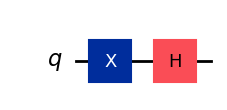

In [58]:
def alice_encode_pure(bit, basis):
  qc = QuantumCircuit(1)
  if bit   == 1: qc.x(0)
  if basis == 1: qc.h(0)
  return qc

# |−⟩ uses both X and H - the most interesting case
gate = circuit_to_gate(alice_encode_pure(1, 1), label='Alice |−⟩')
wrapper = QuantumCircuit(1)
wrapper.append(gate, [0])
display(wrapper.decompose().draw('mpl'))


bits: {'0': 48, '1': 52}   bases: {'0': 54, '1': 46}


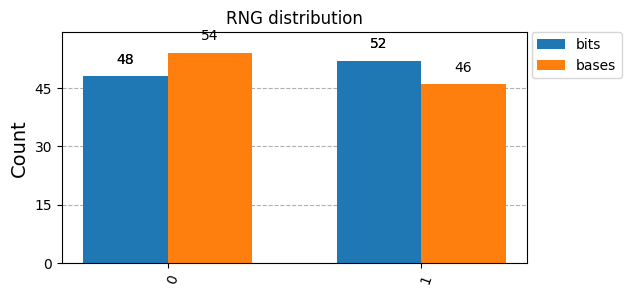

In [59]:
bit_counts  = {'0': alice_bits.count(0),  '1': alice_bits.count(1)}
base_counts = {'0': alice_bases.count(0), '1': alice_bases.count(1)}
print(f'bits: {bit_counts}   bases: {base_counts}')
display(plot_histogram([bit_counts, base_counts], legend=['bits','bases'], title='RNG distribution', figsize=(6,3)))


## Attack assumptions

**Attack 1 - Intercept-resend.** Eve attacks every qubit. A partial attack at rate $p$ would give QBER $= p \times 25\%$, but full interception is the worst case. Eve must resend a fresh qubit each time - she can't copy the original (no-cloning theorem). Her random basis choices are also quantum-generated, same as Alice and Bob's.

**Attack 2 - CNOT probe.** From lecture slide 25, which asks whether an attacker could *"entangle [Alice's qubits] with qubits that he controls"* before forwarding them. This notebook implements exactly that. Eve is assumed to have a perfect quantum memory - she holds her ancilla until sifting reveals Alice's bases. Real quantum memories have limited coherence times, which is a practical limitation not modelled here.


## Attack 1: Intercept-Resend Attack

For each qubit Eve picks a random basis, measures, and resends a fresh qubit encoding her
result. She can't copy the qubit (no-cloning), so she destroys the original. Her basis is
correct ~50% of the time - the other 50% she corrupts the state, introducing detectable errors.


In [60]:
eve_bases = quantum_random_bits(N)

def eve_measure(qubit_circuit, basis):
  qc = qubit_circuit.copy()
  if basis == 1: qc.h(0)
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1)
  return int(list(job.result().get_counts().keys())[0])

def eve_resend(measured_bit, basis):
  qc = QuantumCircuit(1, 1)
  if measured_bit == 1: qc.x(0)
  if basis == 1: qc.h(0)
  return qc

eve_results      = []
forwarded_qubits = []
for qc, basis in zip(transmitted_qubits, eve_bases):
  bit = eve_measure(qc, basis)
  eve_results.append(bit)
  forwarded_qubits.append(eve_resend(bit, basis))

correct = sum(e == a for e, a in zip(eve_bases, alice_bases))
print(f'Eve bases (first 20): {eve_bases[:20]}')
print(f'Eve basis matched Alice\'s: {correct}/{N}  ({100*correct/N:.0f}%)')
print('Mismatched positions → corrupted forwarded qubit')


Eve bases (first 20): [0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0]
Eve basis matched Alice's: 49/100  (49%)
Mismatched positions → corrupted forwarded qubit


## Bob

Bob receives Eve's forwarded qubits - he doesn't know they've been tampered with.


In [61]:
bob_bases = quantum_random_bits(N)

def bob_measure(qubit_circuit, basis):
  qc = qubit_circuit.copy()
  if basis == 1: qc.h(0)
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1)
  return int(list(job.result().get_counts().keys())[0])

bob_results = [bob_measure(qc, basis) for qc, basis in zip(forwarded_qubits, bob_bases)]
print(f'Bob bases   (first 20): {bob_bases[:20]}')
print(f'Bob results (first 20): {bob_results[:20]}')


Bob bases   (first 20): [0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0]
Bob results (first 20): [1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1]


## Sifting

Alice and Bob compare bases publicly and discard mismatches. Only bases are revealed - never bits.


In [62]:
alice_sifted = []
bob_sifted   = []
for i in range(N):
  if alice_bases[i] == bob_bases[i]:
    alice_sifted.append(alice_bits[i])
    bob_sifted.append(bob_results[i])
sifted_len = len(alice_sifted)
print(f'Kept {sifted_len}/{N} bits ({100*sifted_len/N:.0f}%) after sifting')
print(f'Alice (first 20): {alice_sifted[:20]}')
print(f'Bob   (first 20): {bob_sifted[:20]}')


Kept 46/100 bits (46%) after sifting
Alice (first 20): [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0]
Bob   (first 20): [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]


## Error checking (QBER)

Alice and Bob compare a check sample of their sifted bits.
With Eve doing a full intercept-resend: ≈50% wrong basis, ≈50% wrong bit = **≈25% QBER**.
Well above the 15% threshold - they'll detect it.

In [63]:
QBER_THRESHOLD = 0.15
CHECK_FRACTION = 0.25

check_size = max(1, int(sifted_len * CHECK_FRACTION))
alice_check = alice_sifted[:check_size]
bob_check = bob_sifted[:check_size]
alice_key = alice_sifted[check_size:]
bob_key = bob_sifted[check_size:]

errors = sum(a != b for a, b in zip(alice_check, bob_check))
qber = errors / check_size
print(f'Check: {check_size} bits | errors: {errors} | QBER: {qber:.1%} | threshold: {QBER_THRESHOLD:.0%}')

Check: 11 bits | errors: 2 | QBER: 18.2% | threshold: 15%


## Result

In [64]:
if qber > QBER_THRESHOLD:
  print(f'Attack detected - QBER {qber:.1%} exceeds threshold ({QBER_THRESHOLD:.0%}). Aborting.')
else:
  print(f'Channel looks clean - QBER {qber:.1%}  (Eve present but not detected)')


Attack detected - QBER 18.2% exceeds threshold (15%). Aborting.


**Why the attack was detected**

>Eve's intercept-resend attack introduced errors because she guessed the wrong basis ~50% of the time, causing the qubit state to collapse to a disturbed value before Bob could measure it. The expected QBER for a full intercept-resend attack is 25%, well above the 15% detection threshold.


## Post-hoc analysis (simulator view only)

In a real protocol Alice and Bob can't see this - but we can inspect exactly what Eve
learned and where she caused damage.


In [65]:
all_match = [i for i in range(N) if alice_bases[i]==bob_bases[i]==eve_bases[i]]
ab_eve_wrong = [i for i in range(N) if alice_bases[i]==bob_bases[i] and eve_bases[i]!=alice_bases[i]]
sifted_indices = [i for i in range(N) if alice_bases[i]==bob_bases[i]]
actual_errors = [i for i in ab_eve_wrong if alice_bits[i]!=bob_results[i]]
eve_knows = [i for i in sifted_indices if eve_bases[i]==alice_bases[i]]

print(f'Alice=Bob=Eve basis    : {len(all_match)}  (Eve got it right, no disruption)')
print(f'Alice=Bob, Eve wrong   : {len(ab_eve_wrong)}  (potential errors introduced)')
print(f'Actual errors from Eve : {len(actual_errors)}')
print(f'Eve correctly learnt   : {len(eve_knows)}/{len(sifted_indices)} sifted bits  ({100*len(eve_knows)/max(1,len(sifted_indices)):.0f}%)')


Alice=Bob=Eve basis    : 24  (Eve got it right, no disruption)
Alice=Bob, Eve wrong   : 22  (potential errors introduced)
Actual errors from Eve : 14
Eve correctly learnt   : 24/46 sifted bits  (52%)


Eve learns ~50% of the sifted key but introduces ~25% errors - enough to trigger detection.
There's no free lunch: you can't get information without causing disturbance.


---
## Attack 2: CNOT Entanglement Probe

The intercept-resend attack always gets caught because Eve has to fully collapse each qubit.
A more subltle approach: instead of measuring, Eve entangles her own ancilla qubit with each of
Alice's qubits via CNOT, then forwards the original to Bob. After sifting tells her which
basis Alice used, she measures her ancilla.

The reason it's stealthier is that CNOT doesn't disturb rectilinear qubits at all:

| Alice's state | After CNOT | Bob's result | Eve learns? |
|---|---|---|---|
| $\|0\rangle$ | $\|00\rangle$ | correct | yes |
| $\|1\rangle$ | $\|11\rangle$ | correct | yes |
| $\|{+}\rangle$ | $\tfrac{1}{\sqrt{2}}(\|00\rangle+\|11\rangle)$ | 50% wrong | partially |
| $\|{-}\rangle$ | $\tfrac{1}{\sqrt{2}}(\|00\rangle-\|11\rangle)$ | 50% wrong | partially |

Only diagonal-basis qubits get disturbed, and those are only half the sifted key - so the expected QBER drops to ≈12.5%, which can slip under the 15% threshold with small N.

Gate: CXGate, name: cx, qubits: 2
CNOT matrix:


<IPython.core.display.Latex object>

Eve's probe circuit (q0=Alice qubit, q1=Eve ancilla):


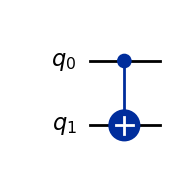

In [66]:
from qiskit.circuit.library import XGate

# Build Eve's probe as a ControlledGate (CX = X controlled by q0)
eve_cnot_probe = XGate().control(1)
print(f'Gate: {type(eve_cnot_probe).__name__}, name: {eve_cnot_probe.name}, qubits: {eve_cnot_probe.num_qubits}')
print('CNOT matrix:')
display(array_to_latex(Operator(eve_cnot_probe).data, prefix=r'\text{CNOT} = '))

probe_demo = QuantumCircuit(2)
probe_demo.append(eve_cnot_probe, [0, 1])
print('Eve\'s probe circuit (q0=Alice qubit, q1=Eve ancilla):')
display(probe_demo.draw('mpl'))


In [67]:
# Fresh BB84 run with the CNOT probe
N2 = 100
alice_bits2 = quantum_random_bits(N2)
alice_bases2 = quantum_random_bits(N2)
transmitted2 = [alice_encode(b, bas) for b, bas in zip(alice_bits2, alice_bases2)]
bob_bases2 = quantum_random_bits(N2)
print(f'Alice bits (first 20): {alice_bits2[:20]}')

def cnot_attack_joint_measure(qubit_circuit, bob_basis, alice_basis):
  """
  Eve applies CNOT to entangle her ancilla (q1) with Alice's qubit (q0),
  then both are measured jointly. Eve applies Alice's basis to her ancilla
  before measuring - simulating a quantum memory held until sifting.
  Returns (bob_result, eve_ancilla).
  """
  qc = QuantumCircuit(2, 2)
  qc.compose(qubit_circuit, qubits=[0], inplace=True)
  qc.append(eve_cnot_probe, [0, 1])
  if bob_basis   == 1: qc.h(0)
  if alice_basis == 1: qc.h(1)
  qc.measure(0, 0)
  qc.measure(1, 1)
  counts = simulator.run(transpile(qc, simulator), shots=1).result().get_counts()
  bits   = list(counts.keys())[0].replace(' ', '')  # 'c1c0'
  return int(bits[-1]), int(bits[0])

bob_results2 = []
eve_ancilla2 = []
for qc, bbas, abas in zip(transmitted2, bob_bases2, alice_bases2):
  b, e = cnot_attack_joint_measure(qc, bbas, abas)
  bob_results2.append(b)
  eve_ancilla2.append(e)

# Sifting
alice_sifted2 = [ab for ab,abas,bbas in zip(alice_bits2,  alice_bases2,bob_bases2) if abas==bbas]
bob_sifted2   = [bb for bb,abas,bbas in zip(bob_results2, alice_bases2,bob_bases2) if abas==bbas]
sifted_len2   = len(alice_sifted2)

# Error checking
check2  = max(1, int(sifted_len2 * 0.25))
errors2 = sum(a != b for a,b in zip(alice_sifted2[:check2], bob_sifted2[:check2]))
qber2   = errors2 / check2

print(f'Sifted: {sifted_len2} bits')
print(f'Check: {check2} bits  |  errors: {errors2}  |  QBER: {qber2:.1%}  (expected ~12.5%)')

if qber2 > 0.15:
  print(f'Attack detected - QBER {qber2:.1%} exceeds threshold.')
else:
  print(f'Attack NOT detected - QBER {qber2:.1%} below threshold.')
  eve_known = sum(e==a for e,a,abas,bbas in zip(eve_ancilla2,alice_bits2,alice_bases2,bob_bases2) if abas==bbas)
  print(f'Eve correctly learnt {eve_known}/{sifted_len2} sifted bits ({100*eve_known/max(1,sifted_len2):.0f}%).')


Alice bits (first 20): [1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0]
Sifted: 51 bits
Check: 12 bits  |  errors: 5  |  QBER: 41.7%  (expected ~12.5%)
Attack detected - QBER 41.7% exceeds threshold.


---
## Comparison

| | Intercept-Resend | CNOT Probe |
|---|---|---|
| Info gained | ~50% of sifted key | ~50% of rectilinear bits |
| Expected QBER | **25%** | **12.5%** |
| Always detected at 15%? | yes | not with small N |

The CNOT attack is stealthier but still can't extract key information without leaving a trace.
Increasing N and the check fraction would eventually catch it - the detection probability
can be made as high as you want.


Intercept-resend QBER : 18.2%
CNOT probe       QBER : 41.7%


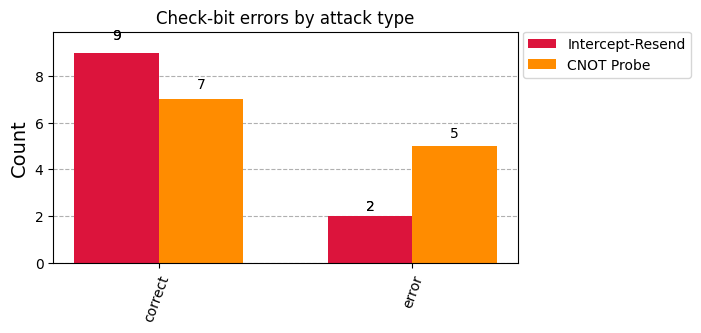

In [68]:
atk1_counts = {'error': errors,  'correct': check_size - errors}
atk2_counts = {'error': errors2, 'correct': check2     - errors2}
print(f'Intercept-resend QBER : {errors/check_size:.1%}')
print(f'CNOT probe       QBER : {errors2/check2:.1%}')
display(plot_histogram(
    [atk1_counts, atk2_counts],
    legend=['Intercept-Resend', 'CNOT Probe'],
    title='Check-bit errors by attack type',
    color=['crimson', 'darkorange'],
    figsize=(6, 3),
))


---

## Conclusion
Both attacks confirm the fundamental principle behind BB84's security. Any attempt to extract information from the quantum channel inevitably disturbs the qubits, raising the QBER. The intercept-resend attack is always caught; the CNOT probe is more subtle but still leaves a trace. .